<a href="https://colab.research.google.com/github/AbdulNaeemB/Lab-Assignments/blob/main/BAYESIAN_ON_IRIS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install torchbnn

In [ ]:
import numpy as np
from sklearn import datasets
import torch
import torch.nn as nn
import torch.optim as optim
import torchbnn as bnn
import matplotlib.pyplot as plt

dataset = datasets.load_iris()

In [ ]:
data = dataset.data
target = dataset.target
data_tensor = torch.from_numpy(data).float()
target_tensor = torch.from_numpy(target).long()

In [ ]:
model = nn.Sequential(bnn.BayesLinear(prior_mu=0,prior_sigma=0.1,in_features=4,out_features=100),nn.ReLU(),bnn.BayesLinear(prior_mu=0,prior_sigma=0.1,in_features=100,out_features=3),)

In [ ]:
cross_entropy_loss = nn.CrossEntropyLoss()
klloss = bnn.BKLLoss(reduction='mean',last_layer_only = False)
klweight = 0.01
optimizer = optim.Adam(model.parameters(),lr=0.01)

In [ ]:
for step in range(3000):
  models = model(data_tensor)
  cross_entropy = cross_entropy_loss(models,target_tensor)
  kl = klloss(model)
  total_cost = cross_entropy + klweight*kl

  optimizer.zero_grad()
  total_cost.backward()
  optimizer.step()

_, predicted = torch.max(models.data,1)
final = target_tensor.size(0)
correct = (predicted == target_tensor).sum()
print(" - Accuracy: %f %%" % (100*float(correct) / final))
print("- CE : %2.2f, KL : %2.2f" % (cross_entropy.item(),kl.item()))

 - Accuracy: 98.000000 %
- CE : 0.05, KL : 2.80


In [ ]:
def draw_graph(predicted):
  fig = plt.figure(figsize = (16,8))
  fig_1 = fig.add_subplot(1,2,1)
  fig_2 = fig.add_subplot(1,2,2)
  z1_plot = fig_1.scatter(data[:,0],data[:,1],target,marker='v')
  z2_plot = fig_2.scatter(data[:,0],data[:,1],predicted)
  plt.colorbar(z1_plot,ax=fig_1)
  plt.colorbar(z2_plot,ax=fig_2)

  fig_1.set_title("REAL")
  fig_2.set_title("PREDICT")

  plt.show()

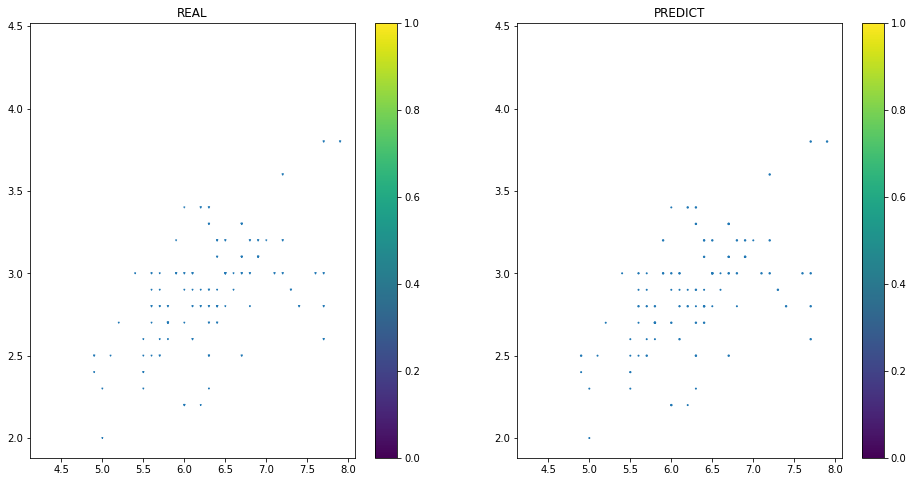

In [ ]:
models = model(data_tensor)
_, predicted = torch.max(models.data,1)
draw_graph(predicted)

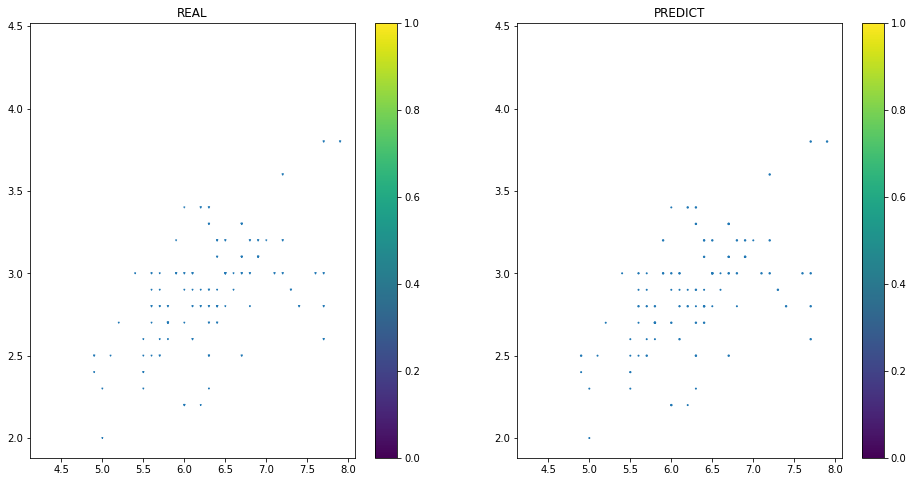

In [ ]:
models = model(data_tensor)
_, predicted = torch.max(models.data, 1)
draw_graph(predicted)